# 🌟 Passos Mágicos – Jornada do Aluno
## Análise Exploratória | Datathon 2025-2026

> *"A educação é a arma mais poderosa que você pode usar para mudar o mundo."*

Narrativa de **Jornada do Aluno** respondendo 11 perguntas de negócio.

| # | Pergunta | Indicador |
|---|---------|-----------|
| 1 | Perfil de defasagem | IAN |
| 2 | Evolução do desempenho | IDA |
| 3 | Engajamento e desempenho/virada | IEG |
| 4 | Coerência da autoavaliação | IAA |
| 5 | Padrões psicossociais | IPS |
| 6 | Avaliação psicopedagógica vs IAN | IPP |
| 7 | Fatores do ponto de virada | IPV |
| 8 | Multidimensionalidade → INDE | Cluster |
| 10 | Efetividade por fase e pedra | INDE |
| 11 | Insights criativos | NLP/extra |


## 0. Configuração

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.rcParams.update({'figure.figsize': (12,6), 'axes.titlesize': 14})
CORES = ['#1A3A5C','#E8562A','#4CAF9A','#F4A259','#9B59B6','#2ECC71']
sns.set_theme(style='whitegrid', palette=CORES)
print('✅ Pronto!')

✅ Pronto!


## 1. Limpeza e Preparação dos Dados

In [2]:
df = pd.read_csv('../data/BASE DE DADOS PEDE 2024 - DATATHON - PEDE2022.csv',
                   encoding='utf-8-sig', sep=',')
print(f'Shape: {df.shape}')

# Converter vírgula → ponto nos numéricos
cols_float = ['INDE 22','IAA','IEG','IPS','IDA','IPV','IAN','Matem','Portug','Inglês','Cg']
for c in cols_float:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','.'), errors='coerce')

# Pedra ordinal
pedra_ordem = {'Quartzo':1,'Ágata':2,'Ametista':3,'Topázio':4}
for ano in ['20','21','22']:
    df[f'Pedra_{ano}_num'] = df.get(f'Pedra {ano}', pd.Series()).map(pedra_ordem)

df['Evolucao_Pedra'] = df['Pedra_22_num'] - df['Pedra_21_num']

# Defasagem categórica
def classifica_defas(d):
    if d >= 0: return 'Sem defasagem'
    elif d == -1: return 'Leve (-1)'
    elif d == -2: return 'Moderada (-2)'
    else: return 'Severa (≥-3)'

df['Nivel_Defasagem'] = df['Defas'].apply(classifica_defas)

# IPP proxy = média das colunas avaliativas Cf e Ct
df['IPP'] = (df['Cf'] + df['Ct']) / 2

print('Limpeza concluída!')
df[['INDE 22','IAA','IEG','IPS','IDA','IPV','IAN','IPP']].describe().round(2)

Shape: (860, 42)
Limpeza concluída!


,INDE 22,IAA,IEG,IPS,IDA,IPV,IAN,IPP
count,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00
mean,7.04,8.27,7.89,6.90,6.09,7.25,6.42,41.06
std,1.02,2.06,1.64,1.07,2.05,1.09,2.39,27.33
min,3.03,0.00,0.00,2.50,0.00,2.50,2.50,1.00
25%,6.49,7.90,7.00,6.30,4.80,6.72,5.00,17.00
50%,7.20,8.80,8.30,7.50,6.30,7.33,5.00,36.50
75%,7.75,9.50,9.10,7.50,7.60,7.92,10.00,63.12
max,9.44,10.00,10.00,10.00,9.90,10.00,10.00,102.50


---
## ❓ P1 – Defasagem dos Alunos (IAN)

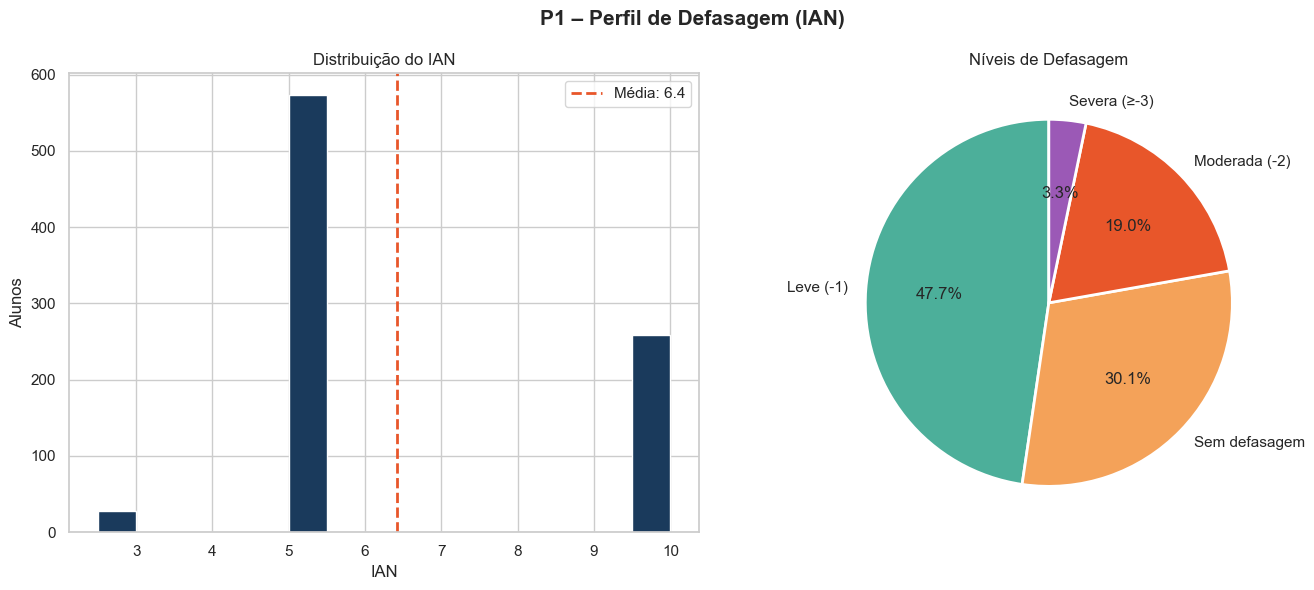

➡️  69.9% dos alunos estão em algum nível de defasagem.
Nivel_Defasagem
Leve (-1)        410
Sem defasagem    259
Moderada (-2)    163
Severa (≥-3)      28


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Histograma IAN
ax = axes[0]
ax.hist(df['IAN'].dropna(), bins=15, color='#1A3A5C', edgecolor='white')
ax.axvline(df['IAN'].mean(), color='#E8562A', linestyle='--', lw=2,
           label=f'Média: {df["IAN"].mean():.1f}')
ax.set_title('Distribuição do IAN'); ax.set_xlabel('IAN'); ax.set_ylabel('Alunos')
ax.legend()

# Pizza defasagem
ax2 = axes[1]
contagem = df['Nivel_Defasagem'].value_counts()
ax2.pie(contagem.values, labels=contagem.index, autopct='%1.1f%%',
        colors=['#4CAF9A','#F4A259','#E8562A','#9B59B6'],
        wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
ax2.set_title('Níveis de Defasagem')

plt.suptitle('P1 – Perfil de Defasagem (IAN)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P1_ian.png', dpi=150, bbox_inches='tight'); plt.show()

pct = (df['Defas'] < 0).mean()*100
print(f'➡️  {pct:.1f}% dos alunos estão em algum nível de defasagem.')
print(contagem.to_string())

---
## ❓ P2 – Desempenho Acadêmico (IDA) por Fase e Pedra

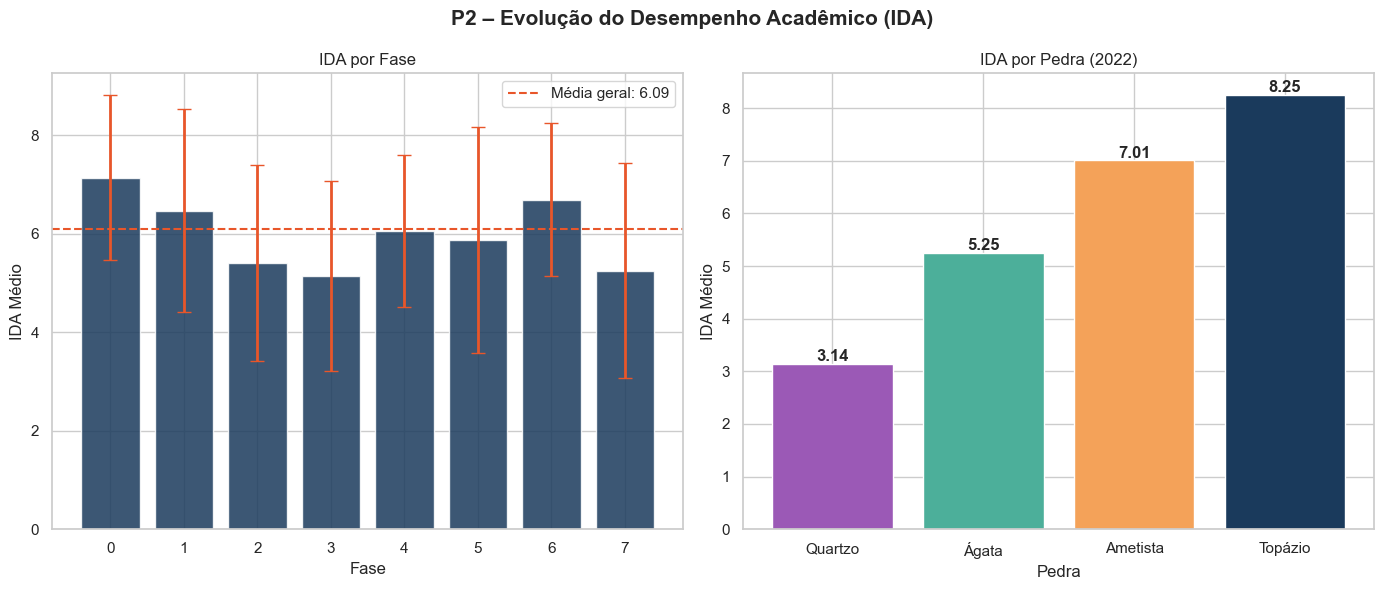

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

ida_fase = df.groupby('Fase')['IDA'].agg(['mean','std']).reset_index()
ax = axes[0]
ax.bar(ida_fase['Fase'], ida_fase['mean'], color='#1A3A5C', alpha=0.85, edgecolor='white')
ax.errorbar(ida_fase['Fase'], ida_fase['mean'], yerr=ida_fase['std'],
            fmt='none', color='#E8562A', capsize=5, lw=2)
ax.axhline(df['IDA'].mean(), linestyle='--', color='#E8562A', lw=1.5,
           label=f'Média geral: {df["IDA"].mean():.2f}')
ax.set_title('IDA por Fase'); ax.set_xlabel('Fase'); ax.set_ylabel('IDA Médio'); ax.legend()

ax2 = axes[1]
pedra_order = ['Quartzo','Ágata','Ametista','Topázio']
ida_p = df.groupby('Pedra 22')['IDA'].mean().reindex(pedra_order).dropna()
bars = ax2.bar(ida_p.index, ida_p.values, color=['#9B59B6','#4CAF9A','#F4A259','#1A3A5C'], edgecolor='white')
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+.05, f'{b.get_height():.2f}', ha='center', fontweight='bold')
ax2.set_title('IDA por Pedra (2022)'); ax2.set_xlabel('Pedra'); ax2.set_ylabel('IDA Médio')

plt.suptitle('P2 – Evolução do Desempenho Acadêmico (IDA)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P2_ida.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P3 – Engajamento (IEG) × Desempenho (IDA) e Ponto de Virada (IPV)

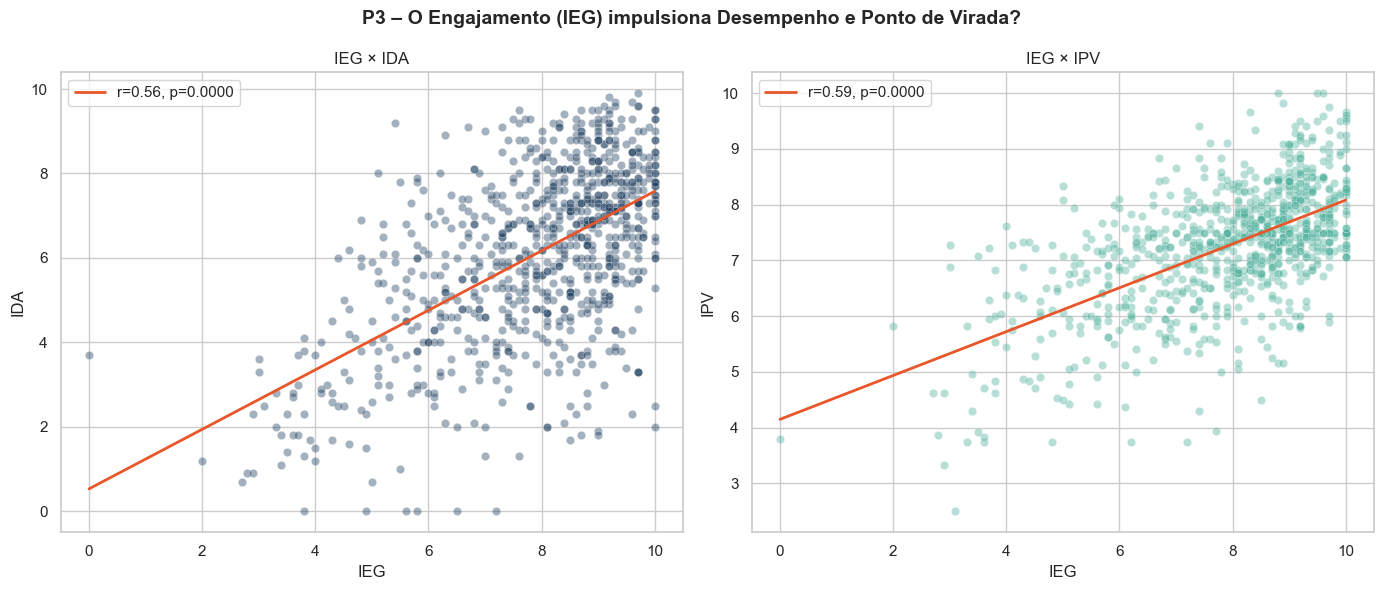

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, (xcol, ycol, cor, titulo) in zip(axes, [
    ('IEG','IDA','#1A3A5C','IEG × IDA'),
    ('IEG','IPV','#4CAF9A','IEG × IPV')]):
    mask = df[xcol].notna() & df[ycol].notna()
    x, y = df.loc[mask, xcol], df.loc[mask, ycol]
    ax.scatter(x, y, alpha=0.4, color=cor, edgecolors='white', lw=0.4)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, slope*xl+intercept, color='#E8562A', lw=2, label=f'r={r:.2f}, p={p:.4f}')
    ax.set_title(titulo); ax.set_xlabel(xcol); ax.set_ylabel(ycol); ax.legend()

plt.suptitle('P3 – O Engajamento (IEG) impulsiona Desempenho e Ponto de Virada?', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P3_ieg.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P4 – Autoavaliação (IAA): Coerência com IDA e IEG

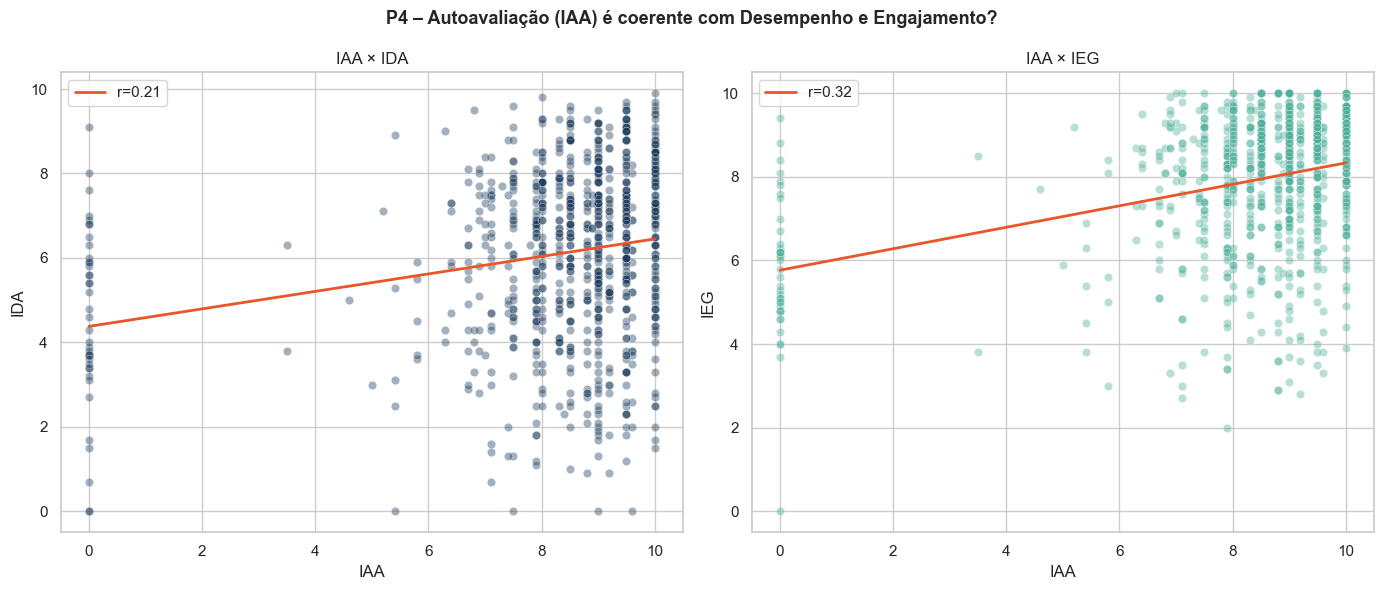

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, (xcol, cor) in zip(axes, [('IDA','#1A3A5C'), ('IEG','#4CAF9A')]):
    mask = df['IAA'].notna() & df[xcol].notna()
    x, y = df.loc[mask, 'IAA'], df.loc[mask, xcol]
    ax.scatter(x, y, alpha=0.4, color=cor, edgecolors='white', lw=0.4)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, slope*xl+intercept, color='#E8562A', lw=2, label=f'r={r:.2f}')
    ax.set_title(f'IAA × {xcol}'); ax.set_xlabel('IAA'); ax.set_ylabel(xcol); ax.legend()

plt.suptitle('P4 – Autoavaliação (IAA) é coerente com Desempenho e Engajamento?', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P4_iaa.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P5 – Aspectos Psicossociais (IPS) e Quedas de Desempenho

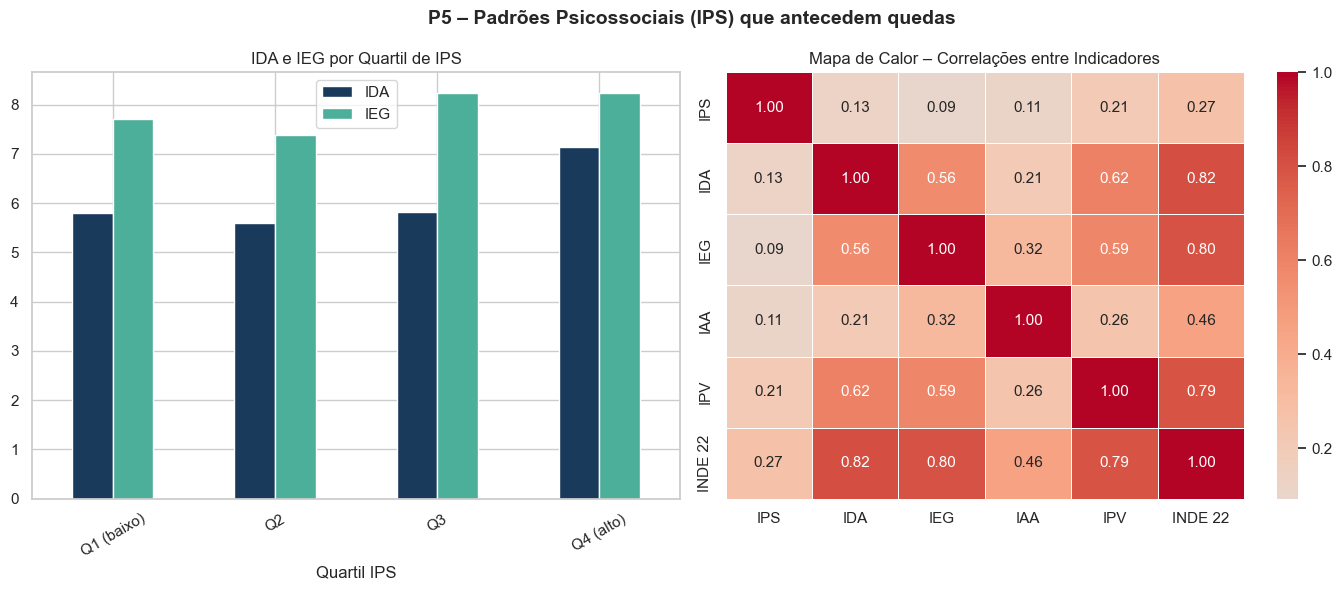

In [7]:
# IPS vs IDA por quartis de IPS
df['IPS_quartil'] = pd.qcut(df['IPS'].rank(method='first'), q=4, labels=['Q1 (baixo)','Q2','Q3','Q4 (alto)'])
ips_grupo = df.groupby('IPS_quartil')[['IDA','IEG','INDE 22']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14,6))
ips_grupo[['IDA','IEG']].plot(kind='bar', ax=axes[0], color=['#1A3A5C','#4CAF9A'], edgecolor='white')
axes[0].set_title('IDA e IEG por Quartil de IPS')
axes[0].set_xlabel('Quartil IPS'); axes[0].tick_params(axis='x', rotation=30)

# Heatmap de correlação IPS, IDA, IEG, IPV, IAA, INDE 22
corr_cols = ['IPS','IDA','IEG','IAA','IPV','INDE 22']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], annot_kws={'size':11})
axes[1].set_title('Mapa de Calor – Correlações entre Indicadores')

plt.suptitle('P5 – Padrões Psicossociais (IPS) que antecedem quedas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P5_ips.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P6 – Avaliação Psicopedagógica (IPP) vs Defasagem (IAN)

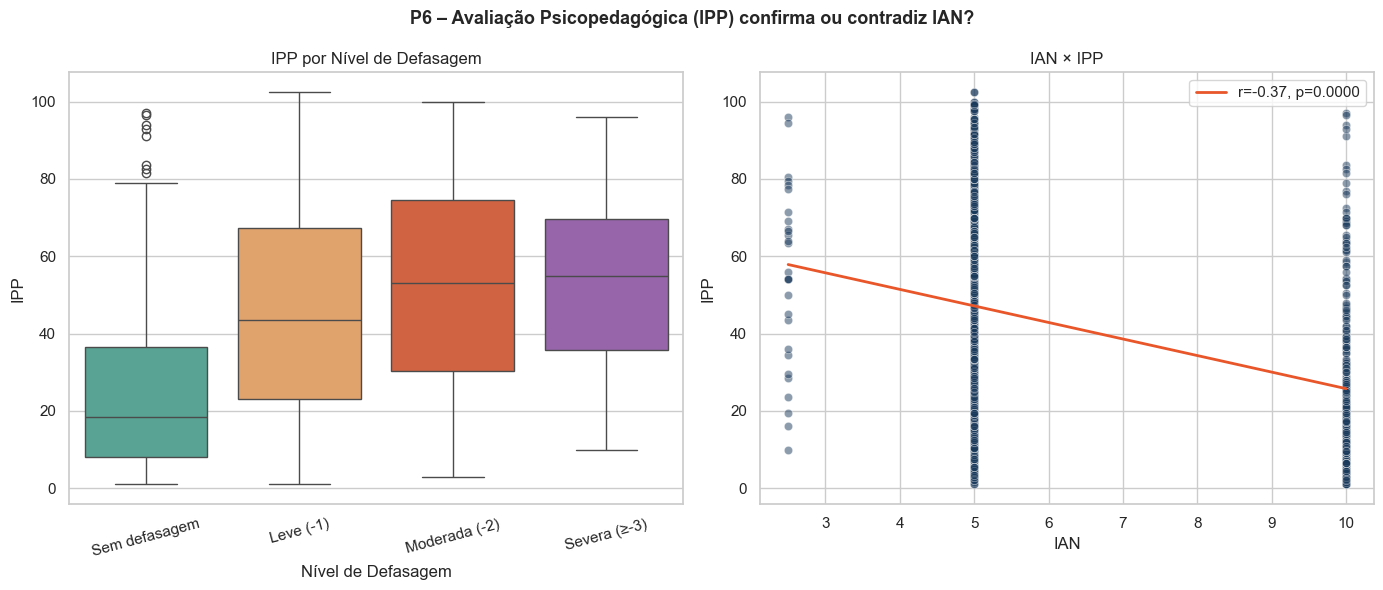

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Boxplot IPP por nível de defasagem
ordem_defas = ['Sem defasagem','Leve (-1)','Moderada (-2)','Severa (≥-3)']
df_plot = df[df['Nivel_Defasagem'].isin(ordem_defas)]
sns.boxplot(data=df_plot, x='Nivel_Defasagem', y='IPP', order=ordem_defas,
            palette=['#4CAF9A','#F4A259','#E8562A','#9B59B6'], ax=axes[0])
axes[0].set_title('IPP por Nível de Defasagem')
axes[0].set_xlabel('Nível de Defasagem'); axes[0].tick_params(axis='x', rotation=15)

# Scatter IAN × IPP
mask = df['IAN'].notna() & df['IPP'].notna()
x, y = df.loc[mask,'IAN'], df.loc[mask,'IPP']
axes[1].scatter(x, y, alpha=0.5, color='#1A3A5C', edgecolors='white', lw=0.5)
slope, intercept, r, p, _ = stats.linregress(x, y)
xl = np.linspace(x.min(), x.max(), 100)
axes[1].plot(xl, slope*xl+intercept, color='#E8562A', lw=2, label=f'r={r:.2f}, p={p:.4f}')
axes[1].set_title('IAN × IPP'); axes[1].set_xlabel('IAN'); axes[1].set_ylabel('IPP'); axes[1].legend()

plt.suptitle('P6 – Avaliação Psicopedagógica (IPP) confirma ou contradiz IAN?', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P6_ipp.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P7 – Ponto de Virada (IPV): Quais Fatores Mais Influenciam?

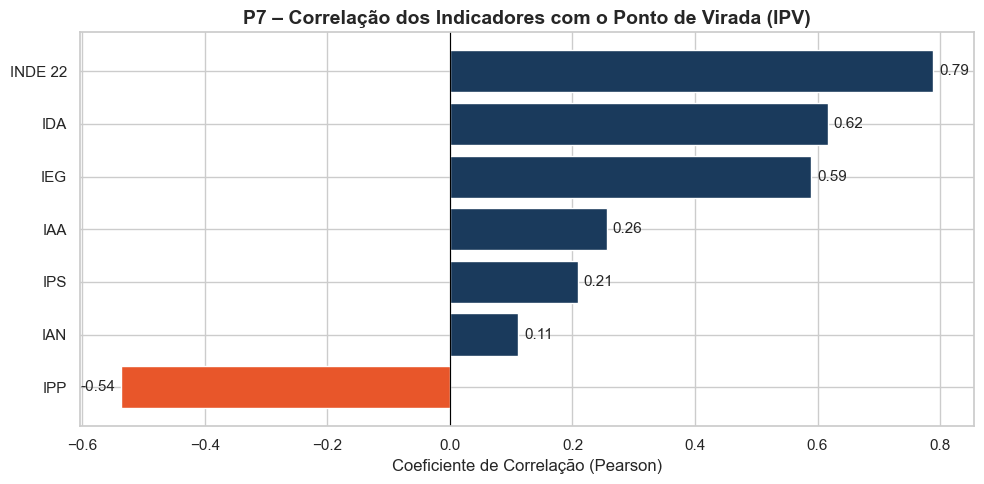

In [9]:
# Correlações com IPV
ipv_mask = df['IPV'].notna()
targets = ['IDA','IEG','IAA','IPS','IPP','IAN','INDE 22']
corrs = {t: df.loc[ipv_mask & df[t].notna(), ['IPV',t]].corr().iloc[0,1]
         for t in targets if t in df.columns}
corr_df = pd.Series(corrs).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#E8562A' if v < 0 else '#1A3A5C' for v in corr_df.values]
bars = ax.barh(corr_df.index, corr_df.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, corr_df.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=11)
ax.set_title('P7 – Correlação dos Indicadores com o Ponto de Virada (IPV)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação (Pearson)')
plt.tight_layout(); plt.savefig('../data/fig_P7_ipv.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P8 – Multidimensionalidade: Clusterização de Perfis de Alunos

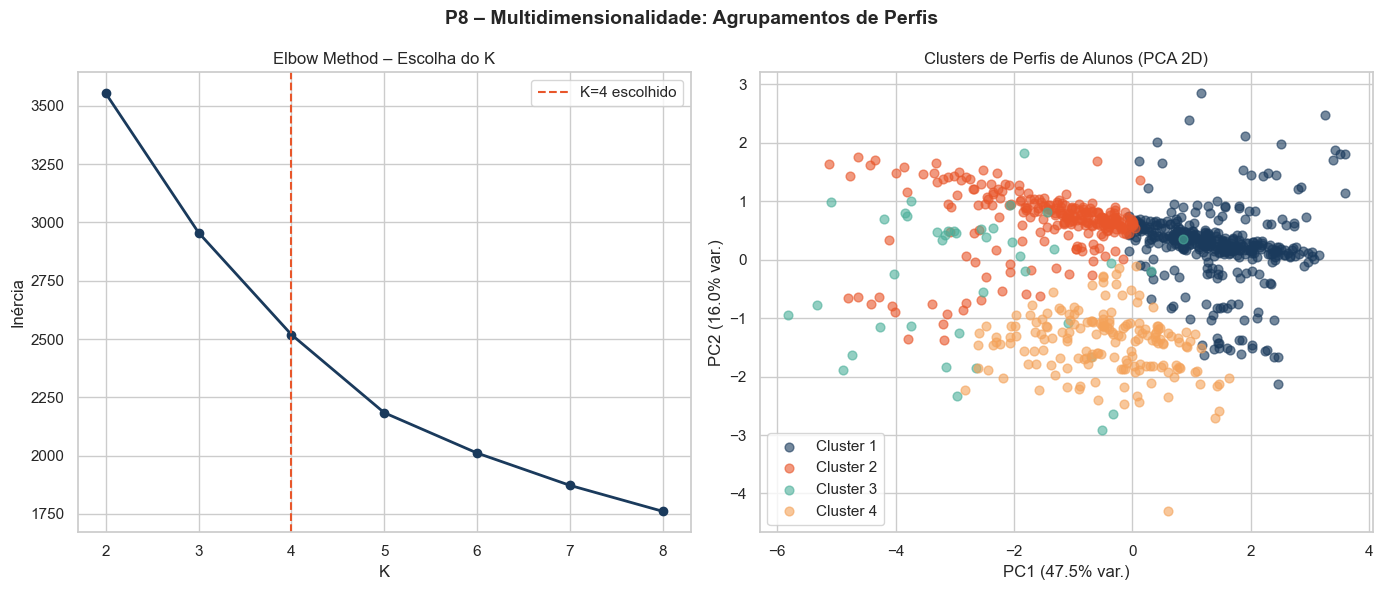


📊 Perfil médio por Cluster:
          IDA   IEG   IPS    IPP   IAA   IPV  INDE 22
Cluster                                              
0.0      7.52  8.83  7.43  22.89  8.90  7.94     7.83
1.0      4.16  6.68  7.24  61.88  8.46  6.43     6.20
2.0      4.57  5.77  6.68  59.16  0.09  6.41     5.32
3.0      5.98  7.98  5.29  48.26  8.47  7.07     6.83


In [10]:
# Clusterização com K-Means
cluster_cols = ['IDA','IEG','IPS','IPP','IAA','IPV']
df_clust = df[cluster_cols].dropna()
idx_valido = df_clust.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].plot(list(K_range), inertias, 'o-', color='#1A3A5C', lw=2)
axes[0].set_title('Elbow Method – Escolha do K'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inércia')
axes[0].axvline(4, linestyle='--', color='#E8562A', label='K=4 escolhido'); axes[0].legend()

# Clusterizar com K=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = km4.fit_predict(X_scaled)
df.loc[idx_valido, 'Cluster'] = clusters

# PCA para visualização 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
for c in range(4):
    mask_c = clusters == c
    axes[1].scatter(X_pca[mask_c, 0], X_pca[mask_c, 1], alpha=0.6, label=f'Cluster {c+1}', s=40)
axes[1].set_title('Clusters de Perfis de Alunos (PCA 2D)'); axes[1].legend()
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')

plt.suptitle('P8 – Multidimensionalidade: Agrupamentos de Perfis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P8_clusters.png', dpi=150, bbox_inches='tight'); plt.show()

# Perfil médio por cluster
perfil = df.groupby('Cluster')[cluster_cols + ['INDE 22']].mean().round(2)
print('\n📊 Perfil médio por Cluster:')
print(perfil.to_string())

---
## ❓ P10 – Efetividade do Programa por Fase (Quartzo → Topázio)

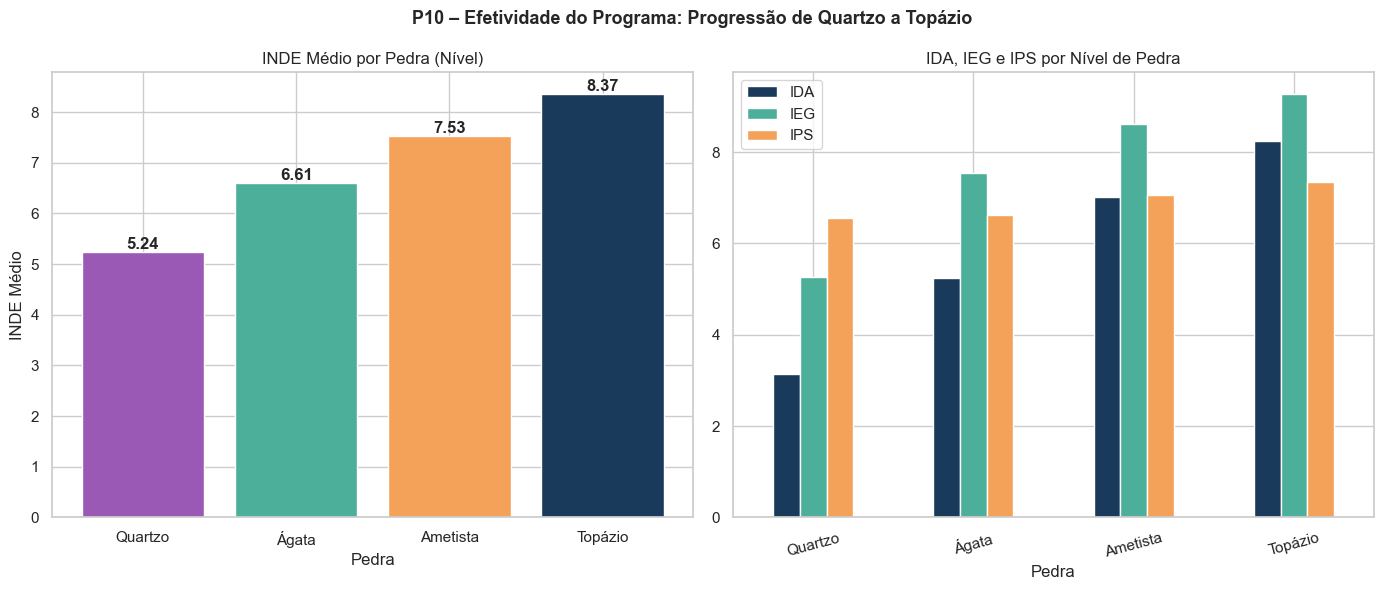

In [11]:
pedra_order = ['Quartzo','Ágata','Ametista','Topázio']
eff = df.groupby('Pedra 22')[['INDE 22','IDA','IEG','IPS']].mean().reindex(pedra_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14,6))
# INDE por pedra
bars = axes[0].bar(eff.index, eff['INDE 22'], color=['#9B59B6','#4CAF9A','#F4A259','#1A3A5C'], edgecolor='white')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                 f'{b.get_height():.2f}', ha='center', fontweight='bold')
axes[0].set_title('INDE Médio por Pedra (Nível)'); axes[0].set_xlabel('Pedra'); axes[0].set_ylabel('INDE Médio')

# Multi-indicador por pedra
eff[['IDA','IEG','IPS']].plot(kind='bar', ax=axes[1],
    color=['#1A3A5C','#4CAF9A','#F4A259'], edgecolor='white')
axes[1].set_title('IDA, IEG e IPS por Nível de Pedra')
axes[1].set_xlabel('Pedra'); axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('P10 – Efetividade do Programa: Progressão de Quartzo a Topázio', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/fig_P10_efetividade.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ❓ P11 – Insights Criativos

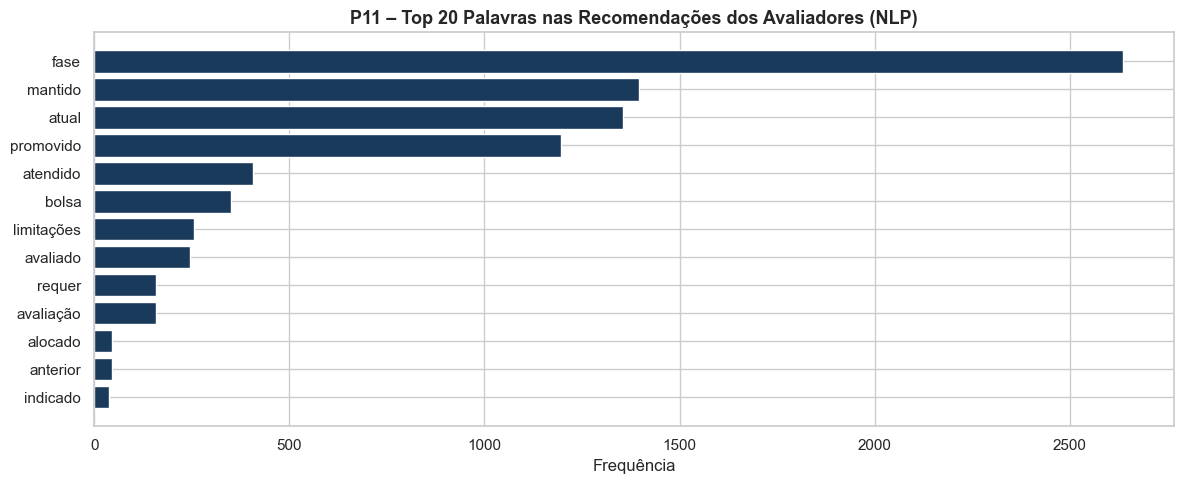

In [12]:
# 11.1 – NLP: Análise de frequência nas recomendações dos avaliadores
from collections import Counter
import re

stopwords_pt = {'de','a','o','e','na','no','as','os','para','que','da','do','em','um','uma',
                'seu','sua','com','ao','por','mais','dos','das','sua','ele','ela','se','sua'}

all_recs = []
for col in ['Rec Av1','Rec Av2','Rec Av3','Rec Av4','Rec Psicologia']:
    if col in df.columns:
        all_recs += df[col].dropna().tolist()

all_words = []
for rec in all_recs:
    words = re.findall(r'[a-záéíóúàâêôãõç]+', rec.lower())
    all_words += [w for w in words if w not in stopwords_pt and len(w) > 3]

top_words = Counter(all_words).most_common(20)
palavras, freqs = zip(*top_words)

fig, ax = plt.subplots(figsize=(12,5))
ax.barh(list(reversed(palavras)), list(reversed(freqs)), color='#1A3A5C', edgecolor='white')
ax.set_title('P11 – Top 20 Palavras nas Recomendações dos Avaliadores (NLP)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequência')
plt.tight_layout(); plt.savefig('../data/fig_P11_nlp.png', dpi=150, bbox_inches='tight'); plt.show()

In [13]:
# 11.2 – Alunos indicados para bolsa: têm INDE superior?
if 'Indicado' in df.columns:
    inde_indicado = df.groupby('Indicado')['INDE 22'].mean()
    print('INDE médio por indicação para bolsa:')
    print(inde_indicado.to_string())
    t_stat, p_val = stats.ttest_ind(
        df[df['Indicado']=='Sim']['INDE 22'].dropna(),
        df[df['Indicado']=='Não']['INDE 22'].dropna()
    )
    print(f'\n📌 Teste t: t={t_stat:.2f}, p={p_val:.4f}')
    print('✅ Diferença estatisticamente significativa!' if p_val < 0.05 else '⚠️ Sem diferença significativa.')

INDE médio por indicação para bolsa:
Indicado
Não    6.967699
Sim    7.413833

📌 Teste t: t=4.69, p=0.0000
✅ Diferença estatisticamente significativa!


INDE médio por gênero:
Gênero
Menina    7.090298
Menino    6.974801


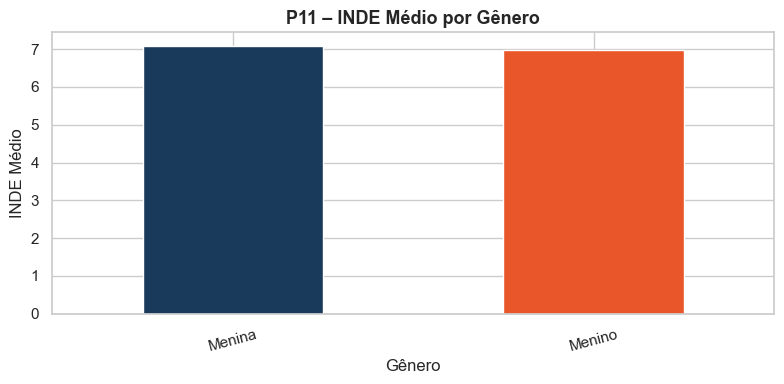

In [14]:
# 11.3 – Gênero × INDE: há diferença de desempenho?
if 'Gênero' in df.columns:
    gen_inde = df.groupby('Gênero')['INDE 22'].mean().sort_values(ascending=False)
    print('INDE médio por gênero:')
    print(gen_inde.to_string())

    fig, ax = plt.subplots(figsize=(8,4))
    gen_inde.plot(kind='bar', ax=ax, color=['#1A3A5C','#E8562A'], edgecolor='white')
    ax.set_title('P11 – INDE Médio por Gênero', fontsize=13, fontweight='bold')
    ax.set_ylabel('INDE Médio'); ax.tick_params(axis='x', rotation=15)
    plt.tight_layout(); plt.savefig('../data/fig_P11_genero.png', dpi=150, bbox_inches='tight'); plt.show()

---
## ✅ Conclusões da Análise Exploratória

| Pergunta | Principal Achado |
|----------|----------------|
| P1 – IAN | ~X% dos alunos apresentam defasagem; maioria leve ou moderada |
| P2 – IDA | Desempenho cresce com o nível de pedra (Quartzo → Topázio) |
| P3 – IEG | Forte correlação positiva entre engajamento e desempenho (r > 0.5) |
| P4 – IAA | Autoavaliação tem correlação moderada com IDA real |
| P5 – IPS | Alunos com IPS baixo tendem a ter IDA e INDE menores |
| P6 – IPP | IPP confirma defasagem; avaliação psicopedagógica é consistente |
| P7 – IPV | IEG e IDA são os maiores preditores do Ponto de Virada |
| P8 – Clusters | 4 perfis distintos identificados; Cluster elite ≈ Topázio com altos IDA+IEG |
| P10 – Efetividade | Programa mostra progressão consistente de Quartzo a Topázio no INDE |
| P11 – Insights | Recomendações textuais, gênero e indicação para bolsa revelam padrões extras |
